In [13]:
%run general_functions.ipynb

In [14]:
vars = {
    'mld':     {'var_name': 'somxl010'                           , 'vmin':0,   'vmax':300, 'unit_chg': 'm',                                       'long': 'Mixed Layer Depth'},
    'npp':     {'var_name': 'bgc_diag_pp', 'conv_term':'31536000', 'vmin':0,   'vmax':300, 'unit_chg': r'mmol C $\mathregular{m^{-2} \ y^{-1}}$', 'long':'Net Primary Production'},
    'sst':     {'var_name': 'sosstsst'                           , 'vmin':0,   'vmax':20,  'unit_chg': r'$^\circ$C',                              'long': 'Sea Surface Temperature'},
    'co2flux': {'var_name': 'co2flux',     'conv_term':'31536000', 'vmin':-0.2,'vmax':0.2, 'unit_chg': r'kg $\mathregular{m^{-2} \ y^{-1}}$',     'long':'$\mathregular{CO_{2}}$ flux'},
}

In [15]:
def month_x_labels(ax):
    
    month_label = ['J','F','M','A','M','J','J','A','S','O','N','D']
    ax.set_xticks(np.arange(1, 13, 1))
    ax.set_xticklabels(month_label, fontsize=16)

In [16]:
def discretised_cmap(ds_in):
    
    vmin, vmax = float(np.nanmin(ds_in.values)), float(np.nanmax(ds_in.values))
    if vmin < 0 < vmax:
        vmax_abs = max(abs(vmin), abs(vmax))
        vmin, vmax = -vmax_abs, vmax_abs
        cmap, extend = cm.prinsenvlag_r, 'both'
    else:
        cmap, extend = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True), 'max'
    cmap, norm = create_discrete_cmap(cmap, 20)

    return cmap, extend

In [17]:
def monthly_means(data, var):

    attrs = data[var].attrs
    data = data.sel(time_counter=slice('2090','2100'))
    data = seasonal_avg(data, var)
    data[var] = data[var].T

    data[var].attrs = attrs

    return data

In [18]:
def coastline_mask(data_path, var):
    
    if var in ['sosstsst','bgc_diag_pp']:
        alk_mask = alk_mask.sel(x=slice(519, 595), y=slice(329, 435)) # m-2
    else:
        alk_mask = alk_mask.sel(x=slice(520, 595), y=slice(330, 435)) # m-2
        
    alk_mask = xr.where(alk_mask.notnull(), 1, np.nan)
    alk_mask = alk_mask.where(alk_mask)
    
    return alk_mask

In [19]:
def depth_mask(d, var, depth, mask):

    ds = copy.deepcopy(d)
    attrs = ds[var].attrs.copy()
    
    ds = ds.where(ds)
    ds[var] = ds[var].notnull().astype(int)

    ds[var] = ds[var] * mask
    
    mask_sum = ds[var].sum(dim=depth).astype(int)
    
    depth_levels = xr.DataArray(d[depth].values, dims=[depth], coords={depth: d[depth]})
    mask_depth_values = mask_sum.copy()
    
    for i, depth_value in enumerate(depth_levels):
        mask_depth_values = mask_depth_values.where(mask_sum != i + 1, depth_value)
    
    mask_depth_values = mask_depth_values.where(mask_depth_values.notnull())
    mask_depth_values = mask_depth_values.where(mask_depth_values).isel(time_counter=0)
    
    return mask_depth_values

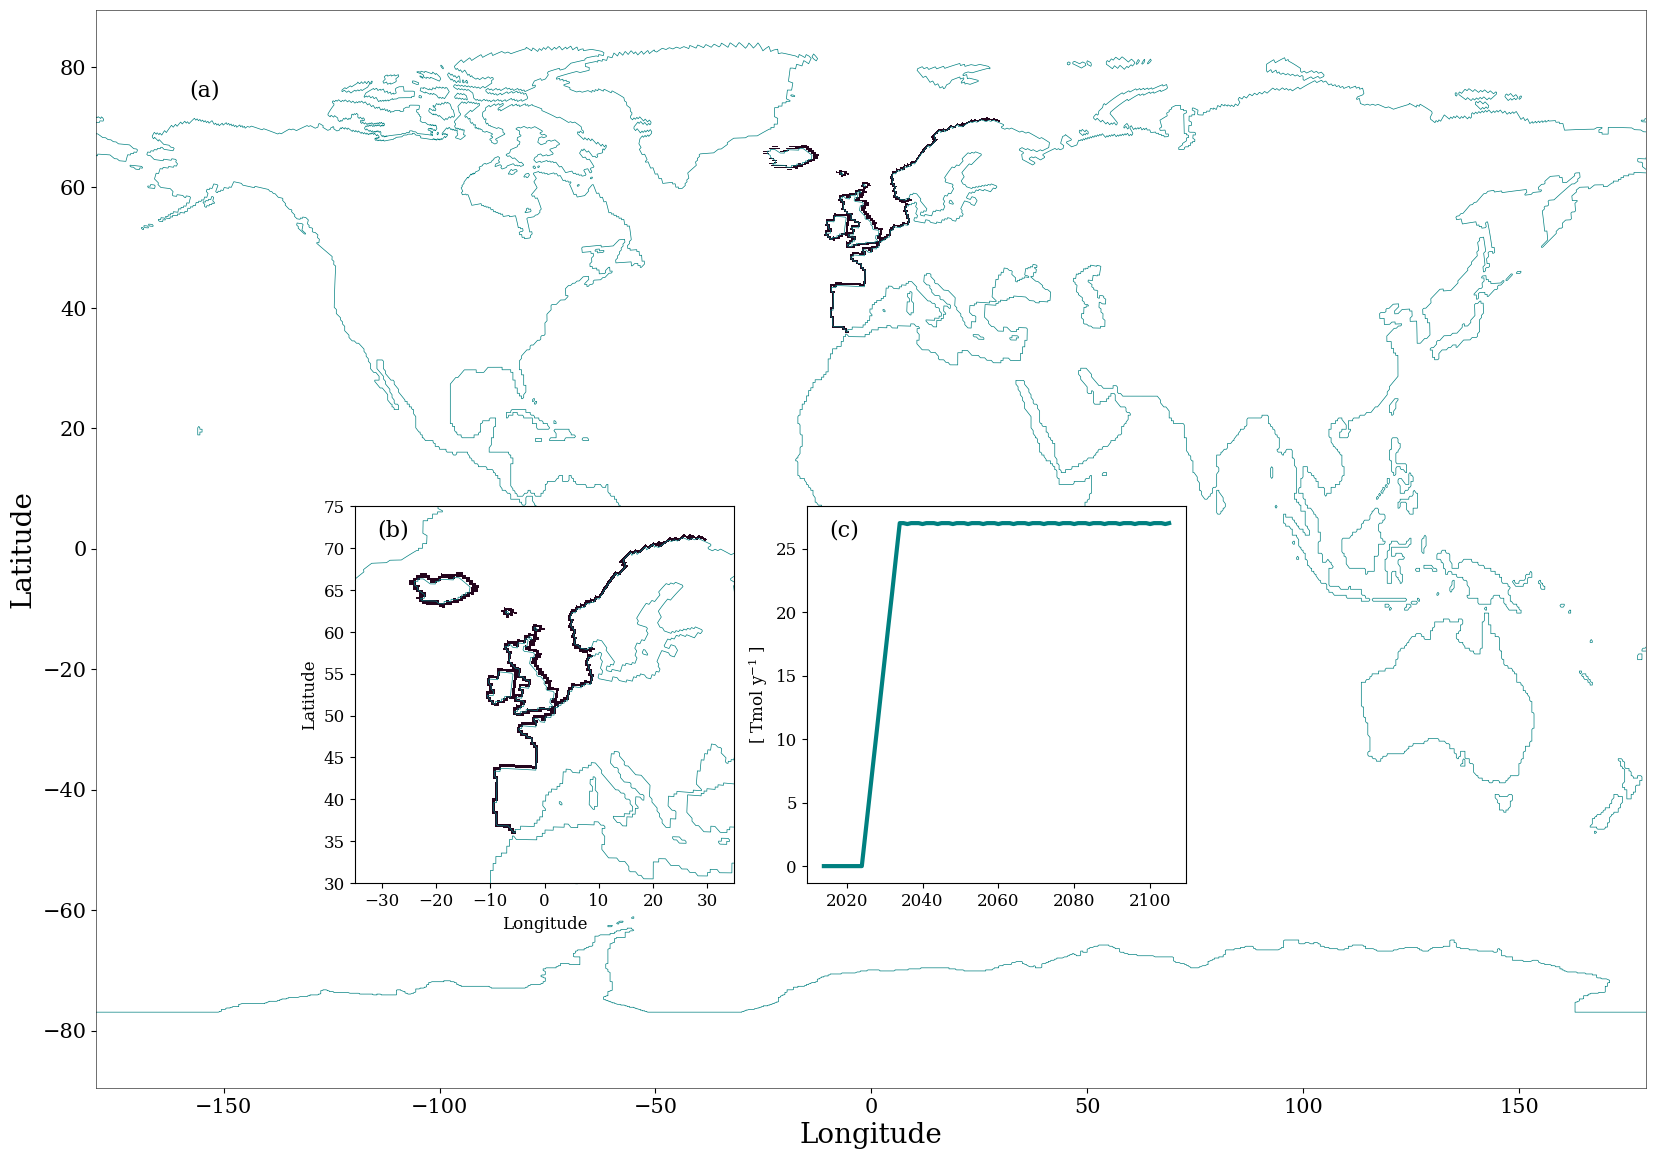

In [20]:
fig, ax_out = plt.subplots(figsize=(20,14))

alk_mask = xr.open_dataset(data_path + '../alk_mask/alkalinity_mask_timeseries.nc')['alk_flux'].sum('time_counter')
alk_mask = alk_mask.where(alk_mask)
alk_mask = xr.where(alk_mask.notnull(), 1, 0)

mesh_mask_sliced = mesh_mask.where((mesh_mask['nav_lon']>-40) & (mesh_mask['nav_lon']<55) & (mesh_mask['nav_lat']>25) & (mesh_mask['nav_lat']<80), drop=True)
alk_mask_sliced = alk_mask.where((alk_mask['nav_lon']>-40) & (alk_mask['nav_lon']<55) & (alk_mask['nav_lat']>25) & (alk_mask['nav_lat']<80), drop=True)

cmap = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True)
cmap, norm = create_discrete_cmap(cmap, 20)

lon, lat = 'nav_lon', 'nav_lat'

x = mesh_mask[lon].values.ravel()
y = mesh_mask[lat].values.ravel()
z = mesh_mask['tmask'].values.ravel()

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
ax_out.tricontour(
    x[mask],
    y[mask],
    z[mask],
    levels=[0.5],
    colors='teal',
    linewidths=.5,
)

ax_out.pcolormesh(
                    alk_mask[lon],
                    alk_mask[lat],
                    alk_mask,
                    vmin=0,vmax=1,
                    cmap = cm.fall_r,
                )

axins = inset_axes(ax_out, width="35%", height="35%", loc="lower left", bbox_to_anchor=(0.16, 0.18, 0.7, 1), bbox_transform=ax_out.transAxes)

im = axins.pcolormesh(
                    alk_mask_sliced[lon],
                    alk_mask_sliced[lat],
                    alk_mask_sliced,
                    cmap = cm.fall_r,
                )

x = mesh_mask_sliced[lon].values.ravel()
y = mesh_mask_sliced[lat].values.ravel()
z = mesh_mask_sliced['tmask'].values.ravel()

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

axins.tricontour(
    x[mask],
    y[mask],
    z[mask],
    levels=[0.5],
    colors='teal',
    linewidths=.5,
)

ax_out.set_xlabel('Longitude')
ax_out.set_ylabel('Latitude')
ax_out.set_xlim(-179.5,179.5)
ax_out.set_ylim(-89.5,89.5)

axins.set_xlabel('Longitude', fontsize=12)
axins.set_ylabel('Latitude', fontsize=12)
# axins.set_xticklabels([])
# axins.set_yticklabels([])
axins.set_xlim(-35,35)
axins.set_ylim(30,75)
axins.tick_params(axis='both', which='major', labelsize=12)

alk_mask = xr.open_dataset(data_path + '../alk_mask/alkalinity_mask_timeseries.nc')['alk_flux']
alk_mask = alk_mask.where(alk_mask)

axins2 = inset_axes(ax_out, width="35%", height="35%", loc="lower right", bbox_to_anchor=(0.01, 0.18, 0.7, 1), bbox_transform=ax_out.transAxes)
alk_mask_weighted = (alk_mask * grid_cell_area).sum(dim=['x', 'y'])
alk_mask_weighted = (alk_mask_weighted * 31536000 * 1.e-18)
alk_integral = alk_mask_weighted.groupby('time_counter.year').mean(dim='time_counter')
axins2.plot(alk_integral['year'], alk_integral, color='teal', linewidth=3)
axins2.set_ylabel(r'[ Tmol $\mathregular{y^{-1}}$ ]', fontsize=12)
axins2.tick_params(axis='both', which='major', labelsize=12)

for ax, letter in zip([ax_out,axins,axins2], string.ascii_lowercase):
    ax.text(0.06, 0.92, f"({letter})", transform=ax.transAxes, fontsize=16)

fineline(ax_out,0.4)
fineline(axins,0.8)
fineline(axins2,0.8)
    
plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/figure1.png')

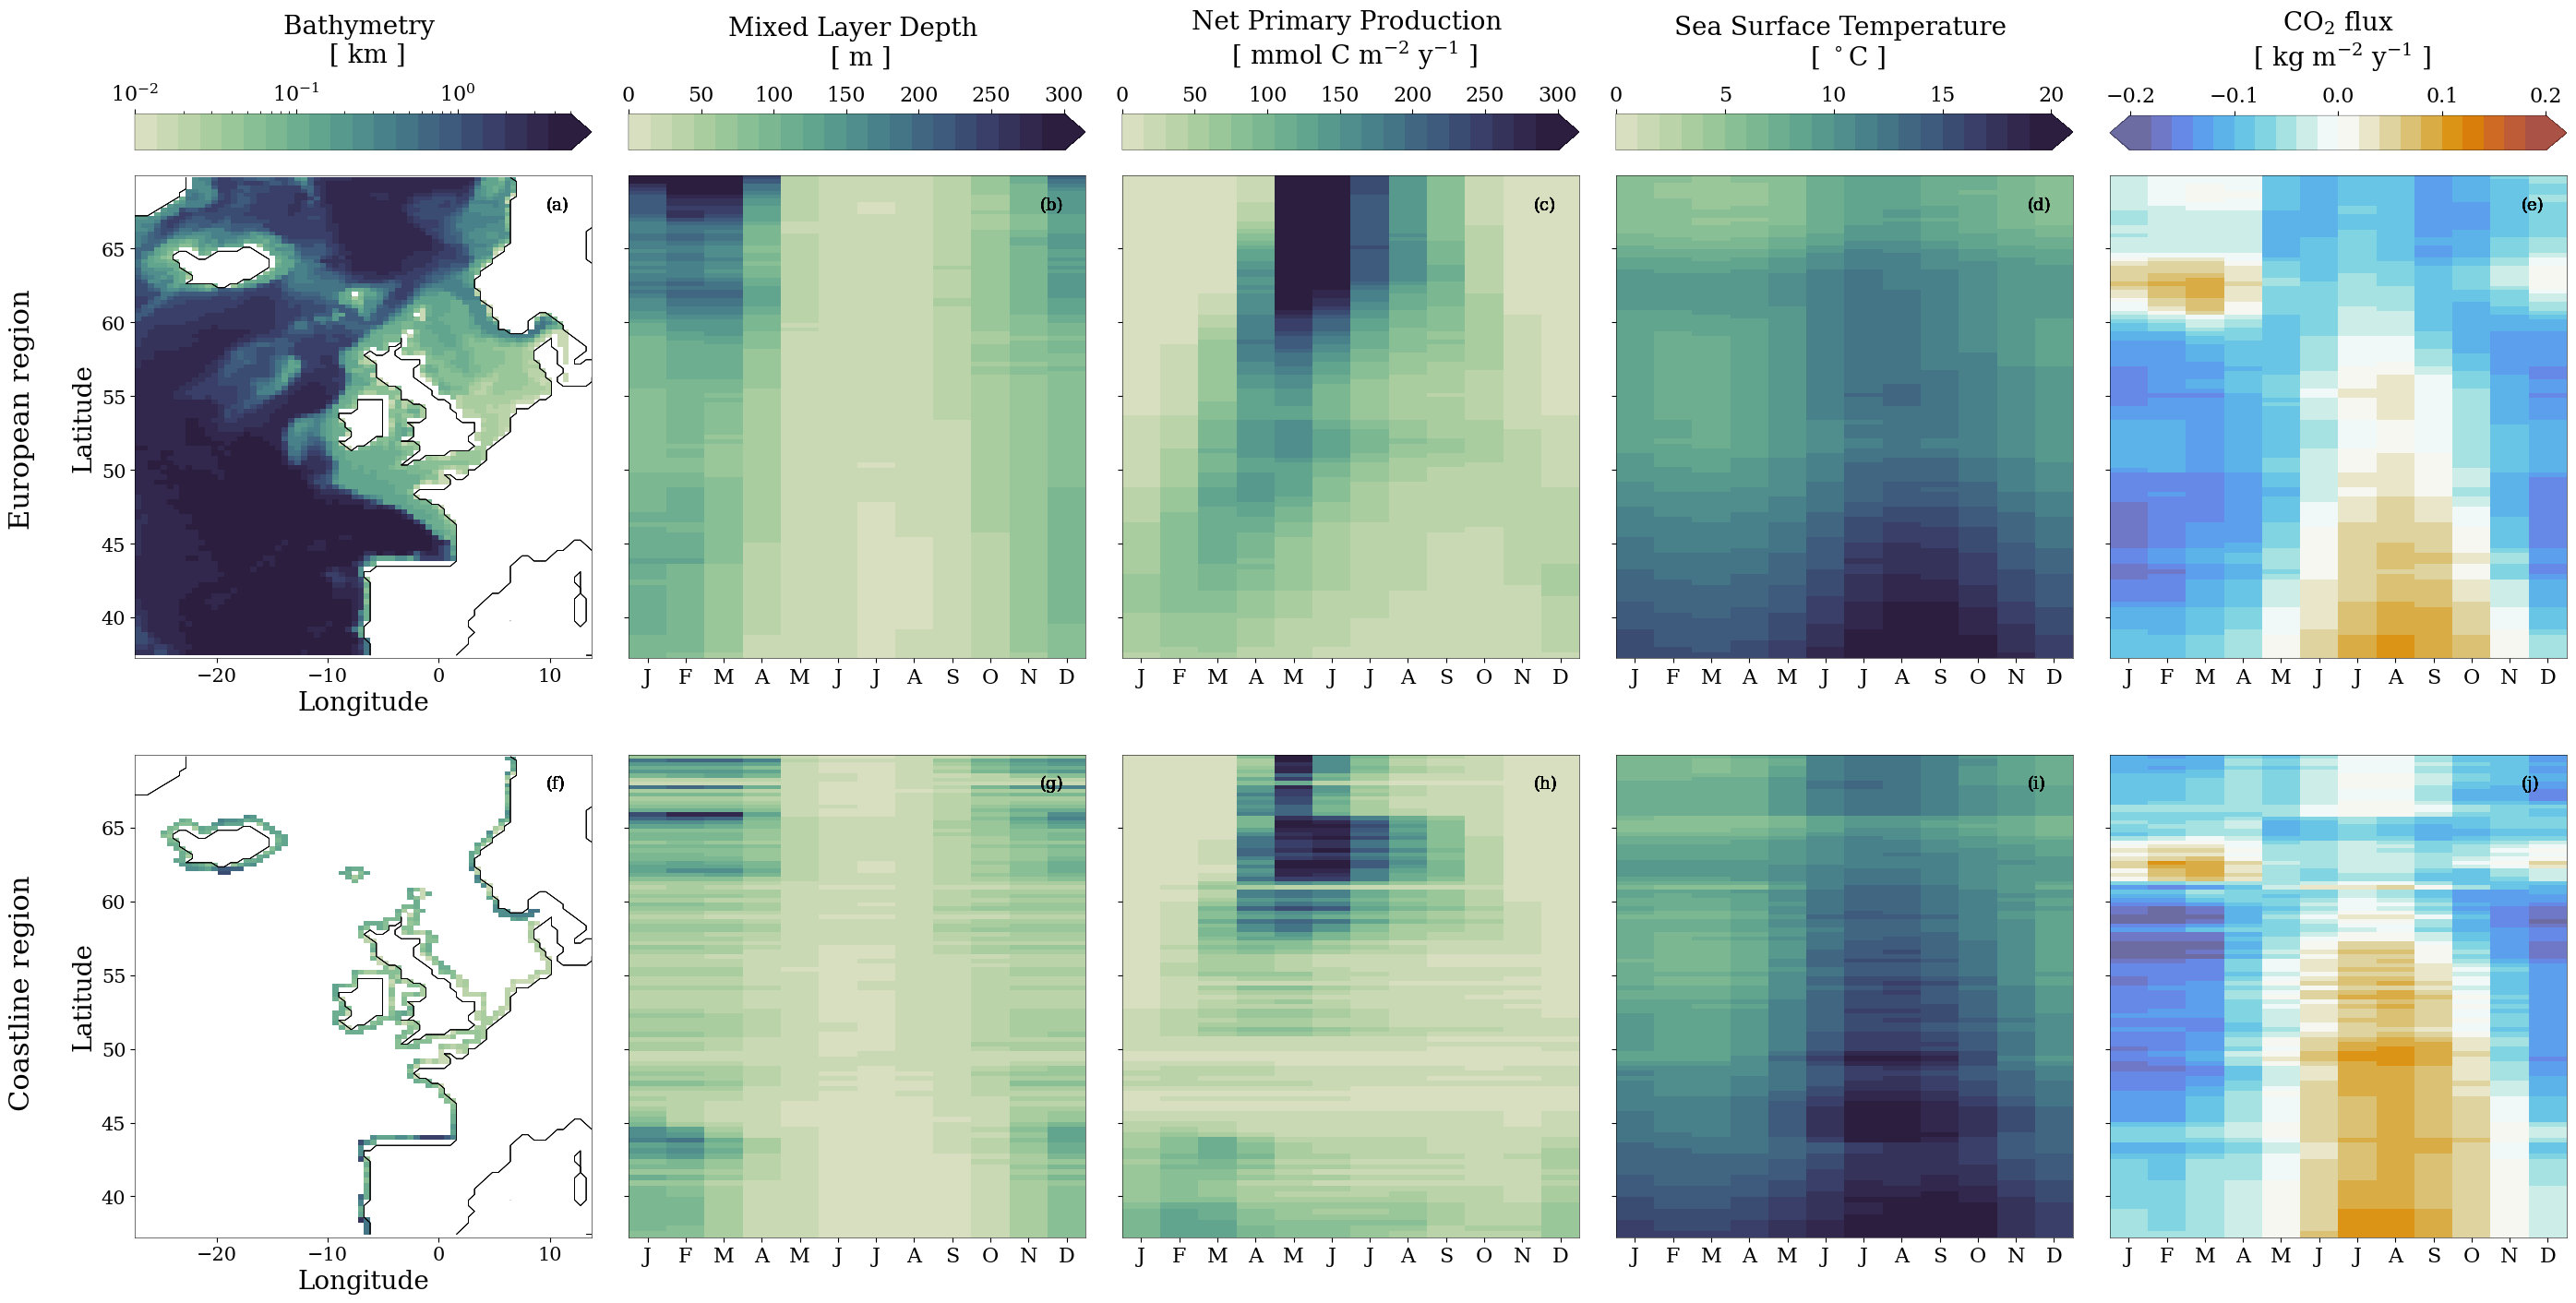

In [12]:
fig, axes = plt.subplots(2, (len(vars)+1), figsize=(34, 18),sharey=True)
plt.subplots_adjust(wspace=0.08)

ims = {}
extends = {}    

for j, (var_key, keys) in enumerate(vars.items()):
    
    var = keys['var_name']
    conv_term = eval(keys['conv_term']) if 'conv_term' in keys else 1
    vmin, vmax = keys['vmin'], keys['vmax']
    
    alk_mask = xr.open_dataset(data_path + '../alk_mask/alkalinity_mask_y2035.nc')['alk_flux']
    alk_mask = alk_mask.where(alk_mask)
    alk_mask = xr.where(alk_mask.notnull(), 1, 0)    
    mesh_mask = xr.open_dataset(data_path+'mesh_mask.nc').isel(z=0,t=0)

    dic = xr.open_dataset(data_path + f'/dic_baseline_126.nc')
    dic_original = dic.isel(deptht=0,time_counter=0)
    lat_dic, lon_dic = dic['nav_lat'].mean('x'), dic['nav_lon'].mean('y')
    dic = dic.assign_coords(y=lat_dic, x=lon_dic)

    polygon_boundaries = polygon_mask(mesh_mask)
    mesh = mesh_mask['tmask'] * polygon_boundaries
    
    if var in ['sosstsst','bgc_diag_pp']:
        grid_cell_sliced = grid_cell_ocean.sel(x=slice(519, 595), y=slice(329, 435))
        mesh = mesh.sel(x=slice(519, 595), y=slice(329, 435))
        alk_mask = alk_mask.sel(x=slice(519, 595), y=slice(329, 435))   

    else:
        grid_cell_sliced = grid_cell_ocean.sel(x=slice(520, 595), y=slice(330, 435))
        mesh = mesh.sel(x=slice(520, 595), y=slice(330, 435))
        alk_mask = alk_mask.sel(x=slice(520, 595), y=slice(330, 435))

        mask_map = depth_mask(dic, 'DIC', 'deptht', mesh)
        alk_map = depth_mask(dic, 'DIC', 'deptht', alk_mask)

    ds_in = xr.open_dataset(data_path + f'/{var_key}_baseline_126.nc')
    lat = ds_in['nav_lat'].mean('x')
    ds_in = ds_in.assign_coords(y=lat)

    if len(ds_in.dims) > 3 and var != 'sosstsst':
        ds_in = vertical_weights(ds_in, var, ds_in, 'deptht', 'sum')
        # ds_in = ds_in.isel(deptht=0)

    ds_in[var] = ds_in[var] * conv_term

    for i, (mask, map) in enumerate(zip([mesh, alk_mask],[mask_map,alk_map])):
        
        for ax, letter in zip(axes.flat, string.ascii_lowercase):
            ax.text(0.9, 0.93, f"({letter})", transform=ax.transAxes, fontsize=20, font=font_prop)
        
        ax_left = axes[i, 0]
        axes_right = axes[i, j+1]  

        ds_out = ((ds_in[var] * grid_cell_sliced * mask).sum('x')) / ((grid_cell_sliced * mask).sum('x'))
            
        ds_out = ds_out.to_dataset(name=var)
        ds_out = monthly_means(ds_out, var)

        cmap_dic, extend = discretised_cmap(map)    
        cmap, extend = discretised_cmap(ds_out[var])    

        data = np.ma.masked_where(map <= 0, map)

        im_map = ax_left.pcolormesh(map['nav_lon'].mean('y'), map['nav_lat'].mean('x'), data * 1.e-3, cmap=cmap_dic, norm=LogNorm(vmin=0.01, vmax=5))
        ax_left.contour(lon_dic, lat_dic, dic_original['DIC'], levels=[0.5], colors='black', linewidths=.5)
        
        im = homvoller(ds_out[var], axes_right, vmin, vmax, 'month', 'y', cmap)
    
        fineline(axes_right,0.4)
        month_x_labels(axes_right)
    
        axes_right.set_ylabel("")
        axes_right.set_xlabel("")
        axes_right.set_title("")
        
        ax_left.set_ylabel("Latitude")
        ax_left.set_xlabel("Longitude")        
        ax_left.set_title("")

        ims[j] = im
        extends[j] = extend
        fineline(axes[i, j],0.4)

for j, (var_key, keys) in enumerate(vars.items()):
    col_axes = [axes[0, j+1], axes[1, j+1]]
    c = fig.colorbar(
        ims[j],
        ax=col_axes,
        aspect=12,
        pad=0.02,
        location="top",
        extend=extends[j]
    )

    c.set_label(f"{keys['long']} \n [ {keys['unit_chg']} ]", labelpad=16)
    c.outline.set_linewidth(0.25)
    c.ax.tick_params(labelsize=16)

c_map = fig.colorbar(im_map, ax=[axes[0,0],axes[1,0]], 
        aspect=12,
        pad=0.02,location='top', extend='max')

c_map.set_label('Bathymetry \n [ km ]', labelpad=16)
c_map.outline.set_linewidth(0.25)
c_map.ax.tick_params(labelsize=16)

row_titles = ['European region', 'Coastline region']
for i, title in enumerate(row_titles):
    fig.text(0.085, 0.54 - i * 0.35,title, ha='left', rotation=90, fontsize=22)

plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/figure2.png')